In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from IPython.display import Image,display
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.checkpoint.memory import MemorySaver
from langchain_tavily import TavilySearch
from langgraph.graph.message import add_messages


In [3]:
llm=init_chat_model("")
tool=TavilySearch(max_results=2)
agent=create_agent(
    model='groq:openai/gpt-oss-120b',
    tools=[tool],
    checkpointer=MemorySaver()
)

In [4]:
config={'configurable':{'thread_id':'chatbot-1'}}
response=agent.invoke({"messages":"what is current AI News, I heared that microsoft cancel there Anthopic Subscription cause it cost more then Humans"},config=config)

In [5]:
for m  in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is current AI News, I heared that microsoft cancel there Anthopic Subscription cause it cost more then Humans
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_d61a797c-b2cc-4cd2-bb91-e41daa5aeddd)
 Call ID: fc_d61a797c-b2cc-4cd2-bb91-e41daa5aeddd
  Args:
    query: Microsoft cancels Anthropic subscription cost more than humans AI news 2024 2025 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "Microsoft cancels Anthropic subscription cost more than humans AI news 2024 2025 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://fortune.com/2026/05/22/microsoft-ai-cost-problem-tokens-agents", "title": "Microsoft reports are exposing AI's real cost problem: Using the tech is more expens

In [6]:
response['messages'][-1].content

'**Current AI‑News Snapshot (late\u202fMay\u202f2026)**  \n\nBelow is a concise briefing of the most talked‑about developments in the AI ecosystem over the past few weeks, followed by a specific look at the Microsoft‑Anthropic story you heard about.\n\n---\n\n## 1. Microsoft pulls back on “Claude\u202fCode” licences  \n| What happened | Why it matters | Source |\n|---------------|----------------|--------|\n| Microsoft has **canceled most of its internal “Claude\u202fCode” licences** (the Anthropic‑powered coding assistant) and is moving engineers to the **GitHub Copilot\u202fCLI** instead. | The decision is driven by **run‑away token costs** when the tool is used at scale. Internal budgets showed that a single Claude\u202fCode seat could cost **hundreds of dollars per day** in API usage, out‑pacing the salary of the employee it was meant to augment. | 【1†L1-L9】【1†L13-L20】 |\n| The cancellation **does not affect Microsoft’s broader Anthropic partnership** (the “Foundry” deal that inclu

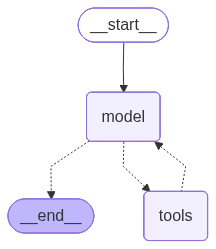

In [7]:
agent